In [ ]:
# Name: best_meeting_place
# Author: Yao Lu
# Date: 2026-07-04
# Description: 计算多位网友的最佳聚会地点

import requests
import time
import os
import numpy as np
import pandas as pd

# ================= 配置区 =================
BAIDU_AK = "PSEbdKaZcIIVP4qwRJ8Gf4nkcj0ObqrN"

# 缓存文件名改为英文
CACHE_FILE = "travel_time_matrix_en.csv"

# 中英文映射字典 (API 查询用中文以保证精度，CSV 保存用英文)
CITY_MAP = {
    "嘉兴市": "Jiaxing", "上海市": "Shanghai", "绍兴市": "Shaoxing", 
    "宿迁市": "Suqian", "赣州市": "Ganzhou", "深圳市": "Shenzhen", "恩施市": "Enshi",
    "北京市": "Beijing", "广州市": "Guangzhou", "成都市": "Chengdu", 
    "重庆市": "Chongqing", "杭州市": "Hangzhou", "武汉市": "Wuhan", 
    "西安市": "Xi'an", "郑州市": "Zhengzhou", "青岛市": "Qingdao", 
    "长沙市": "Changsha", "天津市": "Tianjin", "苏州市": "Suzhou", 
    "南京市": "Nanjing", "东莞市": "Dongguan", "宁波市": "Ningbo", 
    "合肥市": "Hefei", "济南市": "Jinan", "福州市": "Fuzhou", 
    "厦门市": "Xiamen", "昆明市": "Kunming", "沈阳市": "Shenyang", 
    "哈尔滨市": "Harbin", "南昌市": "Nanchang", "贵阳市": "Guiyang", 
    "南宁市": "Nanning", "太原市": "Taiyuan", "石家庄市": "Shijiazhuang",
    "宜昌市": "Yichang"
}

user_cities_cn = ["嘉兴市", "上海市", "绍兴市", "宿迁市", "赣州市", "深圳市", "恩施市"]
candidate_cities_cn = list(CITY_MAP.keys())

# ================= 百度地图 API 工具函数 =================

def get_city_location(city_name):
    """百度地理编码 API: 将城市名转为纬度,经度 (注意百度是 lat,lng)"""
    url = "http://api.map.baidu.com/geocoding/v3/"
    params = {"address": city_name, "output": "json", "ak": BAIDU_AK}
    try:
        res = requests.get(url, params=params).json()
        if res.get("status") == 0:
            loc = res["result"]["location"]
            return f"{loc['lat']},{loc['lng']}"
    except Exception as e:
        print(f"[错误] {city_name} 坐标获取失败: {e}")
    return None

def get_travel_time(origin_loc, dest_loc):
    """
    双重保障：先查公交(含高铁/飞机)，失败则用驾车时间兜底
    """
    # 1. 尝试查询跨城综合公交路线
    transit_url = "http://api.map.baidu.com/direction/v2/transit"
    transit_params = {
        "origin": origin_loc, 
        "destination": dest_loc, 
        "ak": BAIDU_AK
    }
    try:
        res = requests.get(transit_url, params=transit_params).json()
        if res.get("status") == 0 and res.get("result", {}).get("routes"):
            duration = res["result"]["routes"][0]["duration"]
            return duration / 3600.0, "Transit"
    except:
        pass

    # 2. 如果公交路线失败，启动驾车时间作为拓扑距离的合理平替
    driving_url = "http://api.map.baidu.com/directionlite/v1/driving"
    driving_params = {
        "origin": origin_loc, 
        "destination": dest_loc, 
        "ak": BAIDU_AK
    }
    try:
        res = requests.get(driving_url, params=driving_params).json()
        if res.get("status") == 0 and res.get("result", {}).get("routes"):
            duration = res["result"]["routes"][0]["duration"]
            return duration / 3600.0, "Driving"
    except:
        pass

    return 24.0, "Failed"

# ================= 数据抓取与打分 =================

def fetch_and_build_matrix():
    print("1. 正在获取百度地图城市坐标...")
    locations = {}
    for city in candidate_cities_cn:
        loc = get_city_location(city)
        if loc:
            locations[city] = loc
        time.sleep(0.1)
        
    print(f"2. 开始构建耗时矩阵 (带驾车兜底机制)...")
    matrix = np.zeros((len(user_cities_cn), len(candidate_cities_cn)))
    
    for i, u_city in enumerate(user_cities_cn):
        for j, c_city in enumerate(candidate_cities_cn):
            if u_city == c_city:
                matrix[i][j] = 0.0
                continue
                
            u_loc = locations.get(u_city)
            c_loc = locations.get(c_city)
            
            if u_loc and c_loc:
                duration, mode = get_travel_time(u_loc, c_loc)
                matrix[i][j] = round(duration, 2)
                # 打印日志，告诉你它是怎么算出来的
                print(f"   [{CITY_MAP[u_city]} -> {CITY_MAP[c_city]}]: {duration:.1f}h ({mode})")
            else:
                matrix[i][j] = 24.0
            
            # 遵守 API 并发限制
            time.sleep(0.2) 
            
    # 转换为英文列名和行名
    user_cities_en = [CITY_MAP[c] for c in user_cities_cn]
    candidate_cities_en = [CITY_MAP[c] for c in candidate_cities_cn]
    
    df = pd.DataFrame(matrix, index=user_cities_en, columns=candidate_cities_en)
    df.to_csv(CACHE_FILE)
    print(f"\n✅ 数据拉取完成，已缓存至 {CACHE_FILE} (全英文)")
    return df

# 以下是归一化与打分逻辑，与之前一致，仅为英文标签适配
def get_city_weight(city_en):
    tier_1 = ["Beijing", "Shanghai", "Guangzhou", "Shenzhen"]
    tier_new_1 = ["Chengdu", "Chongqing", "Hangzhou", "Wuhan", "Xi'an", "Zhengzhou", "Changsha", "Tianjin", "Suzhou", "Nanjing"]
    if city_en in tier_1: return 1.0
    elif city_en in tier_new_1: return 0.85
    elif city_en in ["Qingdao", "Dongguan", "Ningbo", "Hefei", "Jinan", "Xiamen", "Kunming", "Fuzhou"]: return 0.7
    else: return 0.5

def calculate_best_city(df_matrix, alpha=1.0, beta=1.5, gamma=0.8):
    time_matrix = df_matrix.values
    cost_total = np.sum(time_matrix, axis=0)
    cost_var = np.var(time_matrix, axis=0)
    
    def normalize(array):
        min_val, max_val = np.min(array), np.max(array)
        return np.zeros_like(array) if max_val == min_val else (array - min_val) / (max_val - min_val)
        
    norm_total = normalize(cost_total)
    norm_var = normalize(cost_var)
    weights = np.array([get_city_weight(c) for c in df_matrix.columns])
    
    scores = (alpha * norm_total) + (beta * norm_var) - (gamma * weights)
    
    results = pd.DataFrame({
        'Candidate_City': df_matrix.columns,
        'Total_Time(h)': cost_total,
        'Variance': cost_var,
        'Hub_Bonus': weights,
        'Final_Score': scores
    })
    
    return results.sort_values(by='Final_Score', ascending=True).reset_index(drop=True)

if __name__ == "__main__":
    if not os.path.exists(CACHE_FILE):
        df_time = fetch_and_build_matrix()
    else:
        print(f"📦 Loading cached data from {CACHE_FILE}...")
        df_time = pd.read_csv(CACHE_FILE, index_col=0)
    
    final_ranking = calculate_best_city(df_time, alpha=1.0, beta=1.5, gamma=0.8)
    
    print("\n🏆 Top 10 Meetup Cities:")
    print(final_ranking.head(10).round(2).to_string())

1. 正在获取百度地图城市坐标...
2. 开始构建耗时矩阵 (带驾车兜底机制)...
   [Jiaxing -> Shanghai]: 4.4h (Transit)
   [Jiaxing -> Shaoxing]: 4.6h (Transit)
   [Jiaxing -> Suqian]: 7.4h (Transit)
   [Jiaxing -> Ganzhou]: 8.6h (Transit)
   [Jiaxing -> Shenzhen]: 10.8h (Transit)
   [Jiaxing -> Enshi]: 13.0h (Transit)
   [Jiaxing -> Beijing]: 9.0h (Transit)
   [Jiaxing -> Guangzhou]: 11.3h (Transit)
   [Jiaxing -> Chengdu]: 14.6h (Transit)
   [Jiaxing -> Chongqing]: 14.2h (Transit)
   [Jiaxing -> Hangzhou]: 2.8h (Transit)
   [Jiaxing -> Wuhan]: 8.8h (Transit)
   [Jiaxing -> Xi'an]: 8.4h (Transit)
   [Jiaxing -> Zhengzhou]: 8.2h (Transit)
   [Jiaxing -> Qingdao]: 9.0h (Transit)
   [Jiaxing -> Changsha]: 7.5h (Transit)
   [Jiaxing -> Tianjin]: 8.1h (Transit)
   [Jiaxing -> Suzhou]: 3.7h (Transit)
   [Jiaxing -> Nanjing]: 4.7h (Transit)
   [Jiaxing -> Dongguan]: 16.6h (Transit)
   [Jiaxing -> Ningbo]: 3.4h (Transit)
   [Jiaxing -> Hefei]: 5.4h (Transit)
   [Jiaxing -> Jinan]: 7.3h (Transit)
   [Jiaxing -> Fuzhou]: 5.9h (T

🥇 算法严选前三名城市: ['Wuhan', 'Changsha', 'Nanjing']
✅ 分析图表已保存为 meetup_final_decision.png


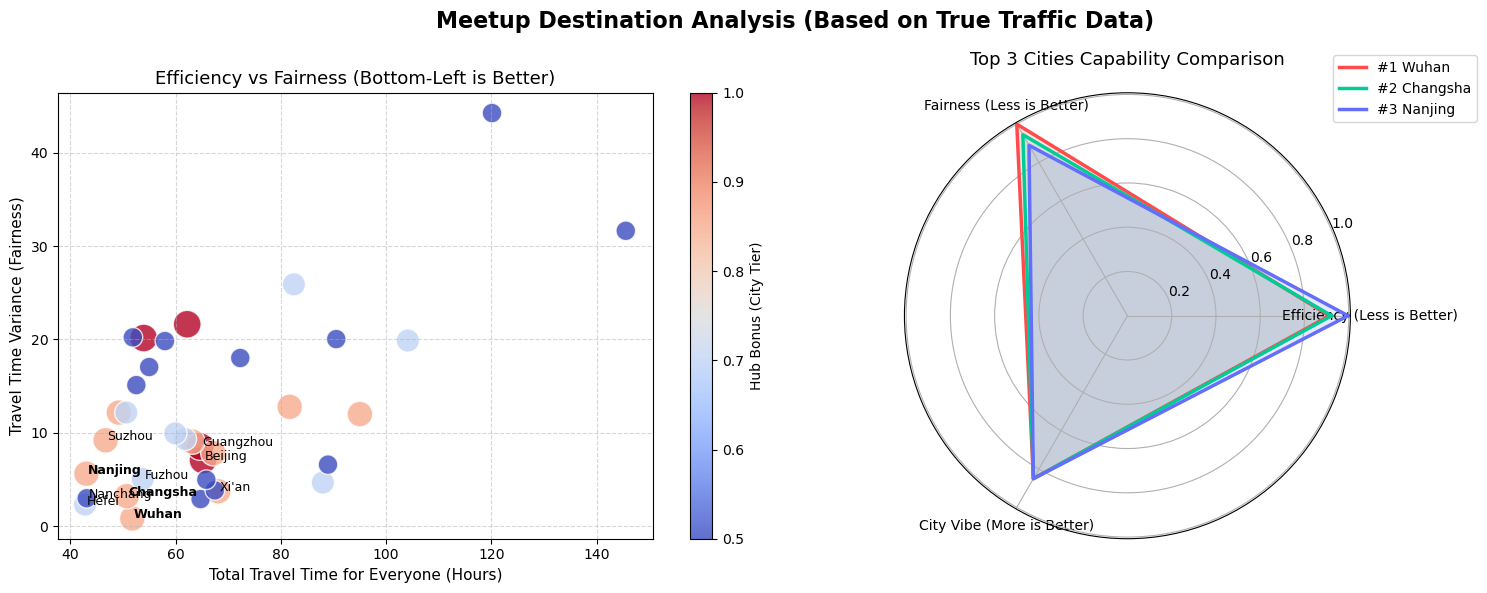

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 城市系数映射函数
def get_city_weight(city_en):
    tier_1 = ["Beijing", "Shanghai", "Guangzhou", "Shenzhen"]
    tier_new_1 = ["Chengdu", "Chongqing", "Hangzhou", "Wuhan", "Xi'an", "Zhengzhou", "Changsha", "Tianjin", "Suzhou", "Nanjing"]
    if city_en in tier_1: return 1.0
    elif city_en in tier_new_1: return 0.85
    elif city_en in ["Qingdao", "Dongguan", "Ningbo", "Hefei", "Jinan", "Xiamen", "Kunming", "Fuzhou"]: return 0.7
    else: return 0.5

# 2. 读取真实的 CSV 矩阵数据
# index_col=0 意味着把第一列（群友城市名）作为行索引
df_matrix = pd.read_csv("travel_time_matrix_en.csv", index_col=0)

# 3. 统计计算
cost_total = df_matrix.sum(axis=0)
cost_var = df_matrix.var(axis=0, ddof=0) # 使用总体方差
hub_bonus = pd.Series([get_city_weight(c) for c in df_matrix.columns], index=df_matrix.columns)

# 组装成分析 DataFrame
df_analysis = pd.DataFrame({
    'Total_Time': cost_total,
    'Variance': cost_var,
    'Hub_Bonus': hub_bonus
})

# 4. 归一化并计算综合得分 (选取 Top 3)
def normalize(s):
    return (s - s.min()) / (s.max() - s.min()) if s.max() != s.min() else s * 0

# 设定你偏好的参数组合 (这里我们按默认的: 效率1.0, 公平1.5, 繁华0.8)
alpha, beta, gamma = 1.0, 1.5, 0.8
df_analysis['Final_Score'] = (alpha * normalize(df_analysis['Total_Time'])) + \
                             (beta * normalize(df_analysis['Variance'])) - \
                             (gamma * df_analysis['Hub_Bonus'])

df_analysis = df_analysis.sort_values(by='Final_Score')
top_3_cities = df_analysis.index[:3].tolist()
print(f"🥇 算法严选前三名城市: {top_3_cities}")

# ================= 画图逻辑 =================
fig = plt.figure(figsize=(16, 6))
fig.suptitle('Meetup Destination Analysis (Based on True Traffic Data)', fontsize=16, fontweight='bold')

# 图1: 散点图 (帕累托前沿)
ax1 = fig.add_subplot(121)
scatter = ax1.scatter(
    df_analysis['Total_Time'], df_analysis['Variance'], 
    s=df_analysis['Hub_Bonus']*400, # 气泡大小代表繁华程度
    c=df_analysis['Hub_Bonus'], cmap='coolwarm', alpha=0.8, edgecolors='white'
)

# 标出前10名的城市名称
for city in df_analysis.index[:10]:
    ax1.text(df_analysis.loc[city, 'Total_Time'] + 0.3, 
             df_analysis.loc[city, 'Variance'], 
             city, fontsize=9, fontweight='bold' if city in top_3_cities else 'normal')

ax1.set_title('Efficiency vs Fairness (Bottom-Left is Better)', fontsize=13)
ax1.set_xlabel('Total Travel Time for Everyone (Hours)', fontsize=11)
ax1.set_ylabel('Travel Time Variance (Fairness)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Hub Bonus (City Tier)')

# 图2: Top 3 城市能力雷达图
metrics = ['Efficiency (Less is Better)', 'Fairness (Less is Better)', 'City Vibe (More is Better)']
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1] 

ax2 = fig.add_subplot(122, polar=True)

# 雷达图数据归一化（将越小越好的指标翻转为越大越好，方便雷达图展示）
df_analysis['Radar_Time'] = 1 - normalize(df_analysis['Total_Time'])
df_analysis['Radar_Var'] = 1 - normalize(df_analysis['Variance'])
df_analysis['Radar_Hub'] = df_analysis['Hub_Bonus']

colors = ['#FF4B4B', '#00CC96', '#636EFA']

for idx, city in enumerate(top_3_cities):
    row = df_analysis.loc[city]
    values = [row['Radar_Time'], row['Radar_Var'], row['Radar_Hub']]
    values += values[:1] 
    
    ax2.plot(angles, values, color=colors[idx], linewidth=2.5, linestyle='solid', label=f"#{idx+1} {city}")
    ax2.fill(angles, values, color=colors[idx], alpha=0.15)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metrics, fontsize=10)
ax2.set_title('Top 3 Cities Capability Comparison', fontsize=13, pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()

# 保存并展示
plt.savefig('meetup_final_decision.png', dpi=300, bbox_inches='tight')
print("✅ 分析图表已保存为 meetup_final_decision.png")
plt.show()